# 05 — Modellvergleich: Naive Baseline, Prophet, Chronos-2, TFT

**Capstone-Projekt · CRISP-DM Phase 4 (Modeling) — zusammenfassender Modellvergleich**

Dieses Notebook fuehrt die vier bisher separat entwickelten Ansaetze zur PM2.5-Prognose in Peking
zusammen und vergleicht sie **auf einheitlicher Basis**:

1. **Seasonal-Naive-Baseline** (letzter Trainingstag, m = 24h)
2. **Prophet** (`03_Modellierung_Prophet_Beijing.ipynb`)
3. **Chronos-2** (`03_Modellierung_Chronos2_variabel_Luftschadstoffe_Beijing_raeumlich_v9.ipynb`)
4. **TFT**, Variante `_v2` (gespeichertes, Optuna-getuntes Modell aus `15_TFT_final_v8.ipynb`)

> ⚠️ **Wichtige Annahmen, die im Auftrag nicht 1:1 spezifiziert waren -- hier transparent gemacht:**
> - Als Testjahr wird **2016/2017** angenommen (Split-Daten `01.09.2016` / `01.11.2016`, Testende
>   `28.02.2017`), passend zum Zeitraum aus der vorherigen TFT-Auswertung.
> - Fuer Prophet **und** Chronos-2 werden **dieselben fuenf Konfigurationsstufen** verwendet (wie in
>   beiden Ursprungs-Notebooks: Basis univariat → +Feiertage → +Wetter-Regressoren → behandelte Daten
>   → +Log-Ziel) -- nur die **Wetter-Regressoren** (nicht SO2/NO2/CO/O3), damit beide Modelle exakt
>   denselben Informationsstand haben.
> - Das TFT-Modell wurde mit festem Horizont **h = 72h** trainiert und kann nicht nativ laenger vorhersagen.
>   Fuer den 3-Wochen-Vergleich (Abschnitt 11) werden daher **sieben aufeinanderfolgende 72h-Bloecke**
>   verkettet (mit den echten historischen Werten als Kontext fuer jeden Block) -- **kein** durchgehender
>   504h-Forecast aus einem Guss. Das ist explizit vermerkt, wo es zum Tragen kommt.
> - Das **rollierende Backtesting** (Abschnitte 9/10) nutzt einen **Schritt ("Versatz") von 8 Tagen**
>   zwischen den Cutoffs -- dieser Wert wird konsistent fuer die MAE-Zeitreihe UND fuer die
>   Durchschnitts-MAE/RMSE-Histogramme verwendet (Wiederverwendung derselben Backtest-Ergebnisse).
> - Konfidenzintervalle sind, wo vorhanden, **80 %** (`quantile_levels=[0.1, 0.5, 0.9]` bei Chronos-2,
>   Prophet-Default `interval_width=0.8`, TFT `TFT-lo-80.0`/`TFT-hi-80.0`). Die Seasonal-Naive-Baseline
>   hat naturgemaess **kein** Unsicherheitsband.

> ⚙️ **Laufzeit-Hinweis:** Dieses Notebook ist **sehr rechenintensiv** (Prophet-Fits, Chronos-2- und
> TFT-Inferenz ueber 11 Stationen x 2 Split-Daten x 5 Konfigurationen x mehrere Backtesting-Cutoffs).
> Ein `SCHNELLTEST`-Schalter (Abschnitt 3) reduziert testweise auf 2 Stationen.

> 📁 **Voraussetzung:** `../data/prepared_chronos/basis/` und `.../behandelt/` (wie in den Chronos-/TFT-
> Notebooks) sowie das gespeicherte Modell unter `../models/tft_final_multivariat_v2/`.


## 1. Bibliotheken

In [1]:
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import holidays

import prophet
from prophet import Prophet

import chronos
from chronos import Chronos2Pipeline

from neuralforecast import NeuralForecast
from sklearn.preprocessing import StandardScaler

print("Prophet-Version:            ", prophet.__version__)
print("chronos-forecasting-Version:", chronos.__version__)
print("torch-Version:              ", torch.__version__, "| CUDA verfuegbar:", torch.cuda.is_available())
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 13, "axes.titleweight": "bold"})

# --- einheitliche Farben je Modell (in allen Plots im Notebook wiederverwendet) --------------------
SLATE          = "#3A4148"    # echte Werte
FARBE_NAIVE    = "#E0912F"    # Seasonal Naive
FARBE_PROPHET  = "#1877F2"    # Prophet (Facebook-Blau)
FARBE_CHRONOS  = "#7B2CBF"    # Chronos-2 (Violett)
FARBE_TFT      = "#2C5F2D"    # TFT (Moosgruen)
RUST           = "#C4471C"    # Referenzlinien (perfekte Vorhersage, Baseline-Niveau)
FARBEN_MODELL  = {"Naive": FARBE_NAIVE, "Prophet": FARBE_PROPHET, "Chronos-2": FARBE_CHRONOS, "TFT": FARBE_TFT}

Importing plotly failed. Interactive plots will not work.


Prophet-Version:             1.3.0
chronos-forecasting-Version: 2.3.1
torch-Version:               2.6.0+cu124 | CUDA verfuegbar: True


## 2. Die vier Modelle im Ueberblick

**Seasonal-Naive-Baseline** -- kein Lernverfahren, sondern eine feste Regel: die Vorhersage fuer eine
Stunde ist der echte Wert derselben Tagesstunde am letzten Trainingstag (`ŷ(t) = Tagesprofil(letzter
Trainingstag)`, Periode m = 24h). Dient als Messlatte -- jedes "echte" Modell sollte sie schlagen
(MASE < 1).

**Prophet** (Meta/Facebook) -- ein additives Komponentenmodell: `y(t) = Trend(t) + Saisonalitaet(t) +
Feiertage(t) + Regressoren(t) + Fehler`. Trend und Saisonalitaeten (jaehrlich/woechentlich/taeglich)
werden per Kurvenanpassung (u. a. Fourier-Reihen fuer die Saisonalitaet) gelernt, zusaetzliche externe
Einfluesse (Wetter, Feiertage) gehen additiv als Regressoren ein. Muss **pro Station neu gefittet**
werden, ist aber schnell zu trainieren und gut interpretierbar (`plot_components`).

**Chronos-2** (Amazon) -- ein vortrainiertes Zeitreihen-**Foundation-Modell** (Transformer-Encoder),
das **zero-shot** vorhersagt: kein eigenes Training auf den Peking-Daten, nur Inferenz mit dem
Kontextfenster (Historie) plus optionalen Kovariaten (Wetter als "bekannte Zukunft", Luftschadstoffe
nur als Kontext). Liefert Quantile (hier 10 %/50 %/90 % → 80 %-Intervall) direkt aus dem Modell.

**TFT** (Temporal Fusion Transformer, hier via `neuralforecast`) -- eine eigens **trainierte**
Deep-Learning-Architektur mit LSTM-Encoder/Decoder, Multi-Head-Attention und variablen-selektiven
Gating-Mechanismen, die *global* ueber alle Stationen gemeinsam (mit `stationstyp` als statischer
Kovariate) trainiert wurde. Anders als Chronos-2 wurde sie **auf genau diese Daten trainiert** (fester
Horizont h = 72h) und liefert ebenfalls Quantil-Vorhersagen (`TFT-lo-80.0`/`TFT-median`/`TFT-hi-80.0`).


## 3. Konfiguration

Zentrale Einstellungen -- **Split-Daten**, **Stationen**, **Horizonte** und Pfade an einem Ort. Die
Datengrundlage ist bei allen vier Modellen dieselbe: die durchgehenden `chronos_<Station>.csv`-Dateien
unter `../data/prepared_chronos/{basis,behandelt}/` (wie im Chronos- und TFT-Notebook) -- Training/Test
werden hier flexibel per Split-Datum geschnitten statt an feste Prophet-CSV-Dateien gebunden zu sein.

In [2]:
SCHNELLTEST = False   # True = nur 2 Stationen (zum Testen); False = alle 11 Stationen

PREP = Path("../data/prepared_chronos")           # {PREP}/basis/chronos_<Station>.csv, {PREP}/behandelt/...
MODELL_DIR_TFT = Path("../models/tft_final_multivariat_v2")   # TFT-Variante _v2 (Optuna-getunt)

# --- Split-Daten & Testzeitraum (siehe Annahme oben: Testjahr 2016/2017) ---------------------------
SPLIT_HAUPT  = "2016-09-01"
SPLIT_ZWEITE = "2016-11-01"
SPLIT_DATEN  = [SPLIT_HAUPT, SPLIT_ZWEITE]
TEST_ENDE    = pd.Timestamp("2017-02-28 23:00:00")   # Testende, wie im Auftrag ("bis zum 28.02.")

HORIZONTE = [8, 24, 48, 72]          # Stunden, wie vorgegeben
HORIZONT_3_TAGE   = 72               # 3 Tage
HORIZONT_3_WOCHEN = 21 * 24          # 3 Wochen = 504 h
ROLLING_VERSATZ_TAGE = 8             # Schritt zwischen Backtest-Cutoffs (siehe Titel-Zelle, Annahme)

SAISON_M = 24                         # Saisonperiode fuer Seasonal Naive & MASE (Tagesmuster)
FREQ = "h"

# --- Stationen: alle ausser Aotizhongxin (Datenluecke, siehe TFT-Notebook) --------------------------
ALLE_STATIONEN = sorted(p.name.replace("chronos_", "").replace(".csv", "")
                       for p in (PREP / "basis").glob("chronos_*.csv"))
STATIONEN = [s for s in ALLE_STATIONEN if s != "Aotizhongxin"]
if SCHNELLTEST:
    STATIONEN = STATIONEN[:2]
STATION_BEISPIEL = "Dongsi" if "Dongsi" in STATIONEN else STATIONEN[0]   # fuer Einzel-Plots
print(f"{len(STATIONEN)} Stationen: {STATIONEN}")
print(f"Beispielstation fuer Einzel-Plots: {STATION_BEISPIEL}")

# --- Regressoren: NUR Wetter, identisch fuer Prophet und Chronos-2 (fairer Vergleich) ---------------
REGRESSOREN = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos"]

# einheitliche Prophet-Grundeinstellung (wie im Prophet-Notebook)
PROPHET_KWARGS = dict(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=True,
                      changepoint_prior_scale=0.05, interval_width=0.8)   # 80 % CI

# Chinesischer Feiertagskalender (wie in beiden Ursprungs-Notebooks)
CN_HOLIDAYS = holidays.country_holidays("CN", years=range(2013, 2018))

def add_feiertag(df):
    d = df.copy()
    d["feiertag"] = d["ds"].dt.date.astype("O").map(lambda t: 1 if t in CN_HOLIDAYS else 0)
    return d

# --- Stationstyp (statischer TFT-Kovariat) -----------------------------------------------------------
STATIONSTYP_TEXT = {
    "Changping": "Vorstadt/Hintergrund", "Dingling": "Vorstadt/Hintergrund", "Dongsi": "Urban",
    "Guanyuan": "Urban", "Gucheng": "Urban/Industrienah", "Huairou": "Vorstadt/Hintergrund",
    "Nongzhanguan": "Urban", "Shunyi": "Vorstadt", "Tiantan": "Urban/Park", "Wanliu": "Urban",
    "Wanshouxigong": "Urban",
}
STATIONSTYP_CODE = {"Urban": 0, "Urban/Park": 0, "Urban/Industrienah": 0,
                    "Vorstadt/Hintergrund": 1, "Vorstadt": 1}

11 Stationen: ['Changping', 'Dingling', 'Dongsi', 'Guanyuan', 'Gucheng', 'Huairou', 'Nongzhanguan', 'Shunyi', 'Tiantan', 'Wanliu', 'Wanshouxigong']
Beispielstation fuer Einzel-Plots: Dongsi


## 4. Hilfsfunktionen: Laden, Split, Regularisieren

In [3]:
def lade_gesamt(variante, station):
    """variante = 'basis' oder 'behandelt'. Laedt EINE durchgehende Zeitreihe fuer `station`
    (kein fester Split in der Datei -- das erlaubt beliebige SPLIT_DATEN weiter unten)."""
    df = pd.read_csv(PREP / variante / f"chronos_{station}.csv", parse_dates=["ds"])
    return df.sort_values("ds").reset_index(drop=True)


def split_bei(df, split_datum):
    """train = alles VOR split_datum, test = alles AB (einschliesslich) split_datum, gekappt auf
    TEST_ENDE."""
    grenze = pd.Timestamp(split_datum)
    train = df[df["ds"] < grenze].reset_index(drop=True)
    test  = df[(df["ds"] >= grenze) & (df["ds"] <= TEST_ENDE)].reset_index(drop=True)
    return train, test


def regularize(df, spalten=None):
    """Luecken-freies Stundenraster; numerische Spalten interpoliert, 'feiertag' vorwaerts gefuellt."""
    spalten = spalten or [c for c in df.columns if c != "ds"]
    d = df.set_index("ds").sort_index()
    voll = pd.date_range(d.index.min(), d.index.max(), freq=FREQ)
    d = d.reindex(voll)
    for c in spalten:
        d[c] = d[c].ffill().bfill() if c == "feiertag" else d[c].interpolate(limit_direction="both")
    d.index.name = "ds"
    return d.reset_index()

## 5. Fehlermaße

In [4]:
def mae(y, yhat):  return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(yhat, float))))
def rmse(y, yhat): return float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(yhat, float)) ** 2)))
def mape(y, yhat):
    y = np.asarray(y, float); yhat = np.asarray(yhat, float); m = y > 0
    return float(np.mean(np.abs((y[m] - yhat[m]) / y[m])) * 100) if m.any() else np.nan

def mase_skala(train_y, m=SAISON_M):
    a = np.asarray(train_y, dtype=float)
    return float(np.nanmean(np.abs(a[m:] - a[:-m])))

def mase(y, yhat, skala):
    return float(mae(y, yhat) / skala)

def jahres_fehler(out, skala):
    return {"MAE": mae(out["y"], out["yhat"]), "RMSE": rmse(out["y"], out["yhat"]),
            "MASE": mase(out["y"], out["yhat"], skala), "MAPE %": mape(out["y"], out["yhat"])}

def fehler_horizonte(out, skala, horizonte=HORIZONTE):
    o = out.sort_values("ds").reset_index(drop=True)
    zeilen = []
    for h in list(horizonte) + [None]:
        n = len(o) if h is None else min(len(o), h)
        w = o.iloc[:n]
        name = f"{h} h" if h is not None else "ganzes Testfenster"
        zeilen.append({"Horizont": name, "MAE": mae(w["y"], w["yhat"]), "RMSE": rmse(w["y"], w["yhat"]),
                       "MASE": mase(w["y"], w["yhat"], skala), "MAPE %": mape(w["y"], w["yhat"])})
    return pd.DataFrame(zeilen)

## 6. Plot-Funktionen (mit 80 %-Konfidenzintervall, falls vorhanden)

In [5]:
def plot_forecast(out, titel, farbe, tage=1):
    """Tagesmittel-Verlauf: echte Werte vs. Vorhersage, inkl. 80 %-Band falls yhat_lower/upper vorhanden."""
    g = out.set_index("ds").resample(f"{tage}D").mean()
    plt.figure(figsize=(12, 4))
    if "yhat_lower" in g and "yhat_upper" in g:
        plt.fill_between(g.index, g["yhat_lower"], g["yhat_upper"], color=farbe, alpha=0.18,
                         label="80 %-Intervall")
    plt.plot(g.index, g["y"], color=SLATE, lw=1.4, label="echte Werte")
    plt.plot(g.index, g["yhat"], color=farbe, lw=1.6, label="Vorhersage")
    plt.ylabel("PM2.5 (µg/m³)"); plt.title(titel); plt.legend(loc="best"); plt.tight_layout(); plt.show()


def plot_horizonte(out, titel, skala, farbe, horizonte=HORIZONTE):
    """Stuendliche Ansicht je Horizont (8/24/48/72h), inkl. 80 %-Band."""
    o = out.sort_values("ds").reset_index(drop=True)
    fig, axes = plt.subplots(len(horizonte), 1, figsize=(12, 3.0 * len(horizonte)))
    for ax, h in zip(np.atleast_1d(axes), horizonte):
        w = o.iloc[:h]
        if "yhat_lower" in w and "yhat_upper" in w:
            ax.fill_between(w["ds"], w["yhat_lower"], w["yhat_upper"], color=farbe, alpha=0.18)
        ax.plot(w["ds"], w["y"], color=SLATE, lw=1.5, marker="o", ms=3, label="echt")
        ax.plot(w["ds"], w["yhat"], color=farbe, lw=1.8, marker="o", ms=3, label="Vorhersage")
        m_ = mase(w["y"], w["yhat"], skala)
        ax.set_title(f"{titel} — erste {h} h  (MASE {m_:.2f})", fontsize=10)
        ax.set_ylabel("PM2.5"); ax.legend(loc="best", fontsize=8)
    plt.tight_layout(); plt.show()

## 7. Naive Baseline

Definition und eine Beispiel-Prognose fuer `STATION_BEISPIEL`, Split am `SPLIT_HAUPT` (01.09.2016),
Testfenster bis `TEST_ENDE` (28.02.2017) -- wie im Auftrag verlangt.

In [6]:
def seasonal_naive(train, test, m=SAISON_M):
    """Tagesprofil des letzten Trainingstages, wiederholt ueber den gesamten Testzeitraum."""
    profil = (train.sort_values("ds").tail(m)
                    .assign(stunde=lambda d: d["ds"].dt.hour)
                    .set_index("stunde")["y"])
    out = test[["ds", "y"]].copy()
    out["yhat"] = profil.loc[out["ds"].dt.hour].to_numpy()
    return out   # kein yhat_lower/upper -- Baseline hat kein Unsicherheitsband


gesamt_basis_bsp = lade_gesamt("basis", STATION_BEISPIEL)
tr_bsp, te_bsp = split_bei(gesamt_basis_bsp, SPLIT_HAUPT)
SKALA_BSP = mase_skala(tr_bsp["y"])
naive_out_bsp = seasonal_naive(tr_bsp, te_bsp)

tr_min, tr_max = tr_bsp["ds"].min(), tr_bsp["ds"].max()
te_min, te_max = te_bsp["ds"].min(), te_bsp["ds"].max()

print(f"Station: {STATION_BEISPIEL}  |  Split: {SPLIT_HAUPT}  |  Testende: {TEST_ENDE.date()}")
print(f"Training: {tr_min:%d.%m.%Y} - {tr_max:%d.%m.%Y}  ({len(tr_bsp)} h)")
print(f"Test:     {te_min:%d.%m.%Y} - {te_max:%d.%m.%Y}  ({len(te_bsp)} h)")
print(f"MASE-Skala (Training, m=24): {SKALA_BSP:.2f} µg/m³\n")
print("Seasonal Naive -- Fehler je Horizont:")
print(fehler_horizonte(naive_out_bsp, SKALA_BSP).to_string(index=False))


Station: Dongsi  |  Split: 2016-09-01  |  Testende: 2017-02-28
Training: 01.03.2013 - 31.08.2016  (30720 h)
Test:     01.09.2016 - 28.02.2017  (4344 h)
MASE-Skala (Training, m=24): 60.65 µg/m³

Seasonal Naive -- Fehler je Horizont:
          Horizont       MAE       RMSE     MASE     MAPE %
               8 h 26.000000  27.870235 0.428707 372.525478
              24 h 12.041667  17.232479 0.198552 212.016658
              48 h 10.520833  15.377879 0.173475 141.117872
              72 h 13.486111  18.222011 0.222369 135.760021
ganzes Testfenster 89.142624 137.105790 1.469849  88.202935


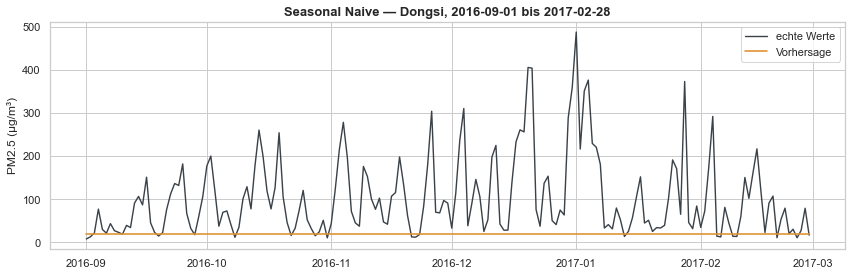

In [7]:
plot_forecast(naive_out_bsp, f"Seasonal Naive — {STATION_BEISPIEL}, {SPLIT_HAUPT} bis {TEST_ENDE.date()}",
             farbe=FARBE_NAIVE, tage=1)

## 8. Prophet: Kernfunktion

Identisch zur Logik aus dem Prophet-Notebook (`add_regressor`, optionales Log-Ziel, `add_country_holidays`),
aber auf Basis von `lade_gesamt()`/`split_bei()` statt fester CSV-Dateien -- so laesst sich dieselbe
Funktion fuer beliebige `SPLIT_DATEN` wiederverwenden.

> ⚠️ Wie im Original-Notebook bekommt Prophet ueber `fut` die **echten** (gemessenen) Wetterwerte des
> Testzeitraums als Regressoren -- ein bewusster Fairness-Kompromiss (entspricht einer perfekten
> Wettervorhersage), identisch fuer Chronos-2 und TFT.

In [8]:
def prophet_fit_predict(train, test, regressoren=None, log=False, feiertage=None, prophet_kwargs=None):
    regressoren = regressoren or []
    prophet_kwargs = prophet_kwargs or PROPHET_KWARGS

    tr = pd.DataFrame({"ds": train["ds"].values})
    tr["y"] = np.log1p(train["y"].values) if log else train["y"].values
    for r in regressoren:
        tr[r] = train[r].values

    m = Prophet(**prophet_kwargs)
    if feiertage:
        m.add_country_holidays(country_name=feiertage)
    for r in regressoren:
        m.add_regressor(r)
    m.fit(tr)

    fut = test[["ds"] + regressoren].copy()
    fc = m.predict(fut)

    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    out = test[["ds", "y"]].merge(fc[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        out[c] = rueck(out[c]).clip(lower=0)
    return out

## 9. Chronos-2: Setup & Kernfunktion

`chronos_predict()` ist (bis auf den Wegfall der Luftschadstoff-/Windaufwaerts-Erweiterungen, die fuer
diesen Modellvergleich nicht gebraucht werden) identisch zur Funktion aus dem Chronos-2-Notebook:
nimmt eine durchgehende Zeitreihe + `split_datum` und trennt selbst. **Stuendliche Aufloesung**
(`AGG_STUNDEN=1`), damit die Horizonte 8/24/48/72h direkt (ohne Aggregations-Umrechnung) mit
Prophet/TFT vergleichbar sind.

In [9]:
chronos_pipeline = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=DEVICE)
print("Chronos-2 geladen auf:", DEVICE)

Chronos-2 geladen auf: cuda


In [10]:
def chronos_predict(gesamt, split_datum, regressoren_zukunft=None, regressoren_vergangenheit=None,
                    feiertag=False, log=False, station="serie"):
    regressoren_zukunft = regressoren_zukunft or []
    regressoren_vergangenheit = regressoren_vergangenheit or []
    alle_regressoren = list(regressoren_zukunft) + list(regressoren_vergangenheit)

    g = regularize(gesamt, spalten=["y"] + alle_regressoren)
    tr, te = split_bei(g, split_datum)

    if feiertag:
        tr, te = add_feiertag(tr), add_feiertag(te)
    zukunft_kov = list(regressoren_zukunft) + (["feiertag"] if feiertag else [])
    alle_kov    = alle_regressoren + (["feiertag"] if feiertag else [])

    tr_c = tr.copy()
    if log:
        tr_c["y"] = np.log1p(tr_c["y"])
    context_df = tr_c[["ds", "y"] + alle_kov].rename(columns={"y": "target"}).copy()
    context_df["id"] = station
    future_df = None
    if zukunft_kov:
        future_df = te[["ds"] + zukunft_kov].copy()
        future_df["id"] = station

    pred_df = chronos_pipeline.predict_df(
        context_df, future_df=future_df, prediction_length=len(te),
        quantile_levels=[0.1, 0.5, 0.9], id_column="id", timestamp_column="ds", target="target", freq=FREQ,
    )
    rueck = (lambda a: np.expm1(a)) if log else (lambda a: a)
    pred_df = pred_df.rename(columns={"0.5": "yhat", "0.1": "yhat_lower", "0.9": "yhat_upper"})
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        pred_df[c] = rueck(pred_df[c])

    out = te[["ds", "y"]].merge(pred_df[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    for c in ["yhat", "yhat_lower", "yhat_upper"]:
        out[c] = out[c].clip(lower=0)
    return out

## 10. TFT (Variante `_v2`): geladenes Modell & Kernfunktion

Laedt das **bereits trainierte** TFT-Modell (`NeuralForecast.load`, kein erneutes Training -- siehe
`16_TFT_modell_laden.ipynb`). Das Modell wurde mit `INPUT_SIZE=336` (14 Tage Kontext) und festem
Horizont `h=72` trainiert; `TRAIN_CUTOFF`/Regressor-Listen entsprechen exakt dem Trainings-Setup
(sonst passt die Standardisierung/`hist_exog`/`futr_exog` nicht zum Modell).

In [11]:
assert MODELL_DIR_TFT.exists(), f"TFT-Modell-Ordner {MODELL_DIR_TFT} nicht gefunden -- Pfad pruefen."
nf_tft = NeuralForecast.load(path=str(MODELL_DIR_TFT))
print("TFT-Modell geladen aus:", MODELL_DIR_TFT)

# --- Konstanten wie beim Training (siehe 15_TFT_final_v8.ipynb / 16_TFT_modell_laden.ipynb) ---------
TFT_TRAIN_CUTOFF = "2016-08-30"     # NUR fuer die Standardisierung der Regressoren -- nicht der Split hier!
TFT_INPUT_SIZE   = 336              # 14 Tage Kontext
TFT_H            = 72               # trainierter Horizont -- laenger geht nur ueber Verkettung (s.u.)

WETTER_REGRESSOREN        = ["TEMP", "DEWP", "PRES", "WSPM", "RAIN", "wd_sin", "wd_cos"]
KALENDER_REGRESSOREN      = ["hour_sin", "hour_cos", "day_sin", "day_cos", "feiertag"]
TFT_REGRESSOREN_ZUKUNFT       = WETTER_REGRESSOREN + KALENDER_REGRESSOREN
TFT_REGRESSOREN_VERGANGENHEIT = ["SO2", "NO2", "CO", "O3"]
TFT_REGRESSOREN_ZU_SKALIEREN  = WETTER_REGRESSOREN[:-2] + TFT_REGRESSOREN_VERGANGENHEIT

def tft_add_time_features(df):
    d = df.copy()
    d["hour_sin"] = np.sin(2*np.pi*d["ds"].dt.hour/24); d["hour_cos"] = np.cos(2*np.pi*d["ds"].dt.hour/24)
    d["day_sin"]  = np.sin(2*np.pi*d["ds"].dt.dayofyear/365.25); d["day_cos"] = np.cos(2*np.pi*d["ds"].dt.dayofyear/365.25)
    return d

def tft_baue_multi(stationen, variante="behandelt"):
    """Baut das multi-DataFrame (regularisiert, Zeit-/Feiertagsfeatures, log1p(y), standardisierte
    Regressoren) fuer TFT -- analog zu 16_TFT_modell_laden.ipynb, hier fuer beliebige Stationslisten."""
    alle_spalten = ["y"] + WETTER_REGRESSOREN + TFT_REGRESSOREN_VERGANGENHEIT
    teile, letzte_ds = [], []
    for st in stationen:
        d = lade_gesamt(variante, st)
        d = regularize(d, spalten=alle_spalten)
        d = tft_add_time_features(d)
        d = add_feiertag(d)
        d = d[["ds"] + alle_spalten + KALENDER_REGRESSOREN].copy()
        d.insert(0, "unique_id", st)
        letzte_ds.append(d["ds"].max())
        teile.append(d)
    m = pd.concat(teile, ignore_index=True)
    datenende = min(letzte_ds)
    m = m[m["ds"] <= datenende].reset_index(drop=True)

    m["y_original"] = m["y"]
    m["y"] = np.log1p(m["y"])

    train_maske = m["ds"] < pd.Timestamp(TFT_TRAIN_CUTOFF)
    scaler = StandardScaler()
    scaler.fit(m.loc[train_maske, TFT_REGRESSOREN_ZU_SKALIEREN])
    m[TFT_REGRESSOREN_ZU_SKALIEREN] = scaler.transform(m[TFT_REGRESSOREN_ZU_SKALIEREN])
    return m, datenende

multi_tft, DATENENDE_TFT = tft_baue_multi(STATIONEN)
stat_df_tft = pd.DataFrame({
    "unique_id": STATIONEN,
    "stationstyp": [float(STATIONSTYP_CODE[STATIONSTYP_TEXT[s]]) for s in STATIONEN],
})
print(f"TFT-Datenende: {DATENENDE_TFT}  |  {len(STATIONEN)} Stationen im multi-DataFrame")

Seed set to 1


TFT-Modell geladen aus: ..\models\tft_final_multivariat_v2
TFT-Datenende: 2017-02-28 23:00:00  |  11 Stationen im multi-DataFrame


In [13]:
def tft_predict_72h(station, split_datum, multi=None, stat_df=stat_df_tft):
    """Ein einzelner 72h-Block ab split_datum fuer `station`, inkl. 80 %-Intervall
    (TFT-lo-80.0/TFT-hi-80.0). Nutzt bei Bedarf ein eigenes multi-DataFrame (fuer die Verkettung
    in tft_predict_lang unten)."""
    multi = multi_tft if multi is None else multi
    split_datum = pd.Timestamp(split_datum)
    kontext_start = split_datum - pd.Timedelta(hours=TFT_INPUT_SIZE + 24)

    kontext_df = multi[(multi["unique_id"] == station) &
                       (multi["ds"] >= kontext_start) & (multi["ds"] < split_datum)]
    fenster = multi[(multi["unique_id"] == station) &
                    (multi["ds"] >= split_datum) & (multi["ds"] < split_datum + pd.Timedelta(hours=TFT_H))]
    if kontext_df.empty or fenster.empty:
        return pd.DataFrame(columns=["ds", "y", "yhat", "yhat_lower", "yhat_upper"])

    stat_zeile = stat_df[stat_df["unique_id"] == station]
    futr_df = fenster[["unique_id", "ds"] + TFT_REGRESSOREN_ZUKUNFT]
    pred = nf_tft.predict(df=kontext_df, static_df=stat_zeile, futr_df=futr_df)
    pred["yhat"] = np.expm1(pred["TFT-median"]).clip(lower=0)
    pred["yhat_lower"] = np.expm1(pred["TFT-lo-80.0"]).clip(lower=0) if "TFT-lo-80.0" in pred.columns else pred["yhat"]
    pred["yhat_upper"] = np.expm1(pred["TFT-hi-80.0"]).clip(lower=0) if "TFT-hi-80.0" in pred.columns else pred["yhat"]

    echte = fenster[["ds", "y_original"]].rename(columns={"y_original": "y"})
    out = echte.merge(pred[["ds", "yhat", "yhat_lower", "yhat_upper"]], on="ds")
    return out


def tft_predict(station, split_datum, horizont=TFT_H, multi=None):
    """Vorhersage fuer beliebigen `horizont`: bis 72h ein einzelner Aufruf, darueber hinaus werden
    mehrere 72h-Bloecke VERKETTET (mit den ECHTEN historischen Werten als Kontext je Block -- siehe
    Warnhinweis im Titel-Abschnitt). Fuer horizont<=72h identisch zu tft_predict_72h()."""
    multi = multi_tft if multi is None else multi
    if horizont <= TFT_H:
        return tft_predict_72h(station, split_datum, multi=multi).iloc[:horizont]

    bloecke = []
    cutoff = pd.Timestamp(split_datum)
    verbleibend = horizont
    while verbleibend > 0:
        n = min(TFT_H, verbleibend)
        block = tft_predict_72h(station, cutoff, multi=multi).iloc[:n]
        if block.empty:
            break
        bloecke.append(block)
        cutoff = cutoff + pd.Timedelta(hours=TFT_H)
        verbleibend -= TFT_H
    if not bloecke:
        return pd.DataFrame(columns=["ds", "y", "yhat", "yhat_lower", "yhat_upper"])
    return pd.concat(bloecke, ignore_index=True)

## 11. Konfigurationsleiter: Prophet & Chronos-2 -- alle Stationen, beide Split-Daten

Dieselbe 5-stufige Konfigurationsleiter wie in den Ursprungs-Notebooks, hier fuer **jede Station**
(außer Aotizhongxin), **beide** Split-Daten (`01.09.2016`, `01.11.2016`) und die Horizonte
`HORIZONTE = [8, 24, 48, 72]` separat ausgewertet:

0. Basis (univariat)
1. Basis + Feiertage
2. Basis + Feiertage + Wetter-Regressoren
3. Behandelt + Feiertage + Wetter-Regressoren
4. Behandelt + Feiertage + Wetter-Regressoren + Log-Ziel

> ⏱️ **Laufzeit:** 2 Split-Daten × 5 Konfigurationen × `len(STATIONEN)` Stationen × 2 Modelle -- bei
> allen 11 Stationen sind das **220 Einzelfits/-inferenzen**. Mit `SCHNELLTEST=True` (Abschnitt 3)
> testweise nur 2 Stationen (40 Laeufe) verwenden.

In [14]:
KONFIGS = {
    "Basis (univariat)":                   dict(variante="basis",     regressoren=[],          feiertag=False, log=False),
    "Basis + Feiertage":                   dict(variante="basis",     regressoren=[],          feiertag=True,  log=False),
    "Basis + Feiertage + Regressoren":     dict(variante="basis",     regressoren=REGRESSOREN, feiertag=True,  log=False),
    "Behandelt + Feiertage + Regressoren": dict(variante="behandelt", regressoren=REGRESSOREN, feiertag=True,  log=False),
    "Behandelt + FT + Reg + Log":          dict(variante="behandelt", regressoren=REGRESSOREN, feiertag=True,  log=True),
}

In [15]:
def sweep_fehler(modellname, predict_fn):
    """Loop ueber Split-Daten x Konfigurationen x Stationen; predict_fn(tr, te, kcfg, station) -> out
    (Spalten ds,y,yhat[,yhat_lower,yhat_upper]). Gibt eine Zeile PRO Horizont zurueck."""
    zeilen = []
    for sd in SPLIT_DATEN:
        for kname, kcfg in KONFIGS.items():
            for st in STATIONEN:
                gesamt = lade_gesamt(kcfg["variante"], st)
                tr, te = split_bei(gesamt, sd)
                if te.empty:
                    continue
                skala = mase_skala(tr["y"])
                out = predict_fn(tr, te, kcfg, st)
                for h in HORIZONTE:
                    w = out.iloc[:h]
                    if w.empty:
                        continue
                    zeilen.append({"Modell": modellname, "Split-Datum": sd, "Konfiguration": kname,
                                   "Station": st, "Horizont": f"{h} h",
                                   "MAE": mae(w["y"], w["yhat"]), "RMSE": rmse(w["y"], w["yhat"]),
                                   "MASE": mase(w["y"], w["yhat"], skala), "MAPE %": mape(w["y"], w["yhat"])})
            print(f"  [{modellname}] fertig: Split {sd} | {kname}")
    return pd.DataFrame(zeilen)


def _prophet_predict_fn(tr, te, kcfg, st):
    return prophet_fit_predict(tr, te, regressoren=kcfg["regressoren"], log=kcfg["log"],
                               feiertage="CN" if kcfg["feiertag"] else None)

def _chronos_predict_fn(tr, te, kcfg, st):
    gesamt = pd.concat([tr, te], ignore_index=True)
    return chronos_predict(gesamt, te["ds"].min(), regressoren_zukunft=kcfg["regressoren"],
                           regressoren_vergangenheit=[], feiertag=kcfg["feiertag"], log=kcfg["log"], station=st)

In [16]:
print("=== Prophet: Konfigurationsleiter ===")
ergebnisse_prophet = sweep_fehler("Prophet", _prophet_predict_fn)

=== Prophet: Konfigurationsleiter ===


11:46:59 - cmdstanpy - INFO - Chain [1] start processing
11:47:13 - cmdstanpy - INFO - Chain [1] done processing
11:47:17 - cmdstanpy - INFO - Chain [1] start processing
11:47:30 - cmdstanpy - INFO - Chain [1] done processing
11:47:33 - cmdstanpy - INFO - Chain [1] start processing


KeyboardInterrupt: 

In [ ]:
print("=== Chronos-2: Konfigurationsleiter ===")
ergebnisse_chronos = sweep_fehler("Chronos-2", _chronos_predict_fn)

In [ ]:
# --- Fehler ausgeben: Mittel ueber alle Stationen je Split-Datum / Konfiguration / Horizont ----------
alle_sweep = pd.concat([ergebnisse_prophet, ergebnisse_chronos], ignore_index=True)
sweep_mittel = (alle_sweep.groupby(["Modell", "Split-Datum", "Konfiguration", "Horizont"])
                [["MAE", "RMSE", "MASE", "MAPE %"]].mean().round(3))

for sd in SPLIT_DATEN:
    print(f"\n########## Split-Datum: {sd} ##########")
    for modell in ["Prophet", "Chronos-2"]:
        print(f"\n--- {modell} (Mittel ueber {len(STATIONEN)} Stationen) ---")
        tab = sweep_mittel.loc[modell, sd].reset_index()
        # in HORIZONTE-Reihenfolge und Konfigurations-Reihenfolge sortieren
        tab["_h_sort"] = tab["Horizont"].map({f"{h} h": h for h in HORIZONTE})
        tab["_k_sort"] = tab["Konfiguration"].map({k: i for i, k in enumerate(KONFIGS)})
        print(tab.sort_values(["_k_sort", "_h_sort"]).drop(columns=["_h_sort", "_k_sort"]).to_string(index=False))

VERGLEICH_SWEEP_CSV = Path("../data/modellvergleich_konfigurationsleiter.csv")
VERGLEICH_SWEEP_CSV.parent.mkdir(parents=True, exist_ok=True)
alle_sweep.to_csv(VERGLEICH_SWEEP_CSV, index=False)
print(f"\ngespeichert -> {VERGLEICH_SWEEP_CSV}")

### Beispielplots (80 %-Intervall) fuer die beste Konfiguration je Modell

Beste Konfiguration nach mittlerem RMSE (ueber alle Stationen, `Behandelt + FT + Reg + Log` in der
Regel), gezeigt fuer `STATION_BEISPIEL` und beide Split-Daten.

In [ ]:
beste_konfig_prophet = (ergebnisse_prophet.groupby("Konfiguration")["RMSE"].mean().idxmin())
beste_konfig_chronos = (ergebnisse_chronos.groupby("Konfiguration")["RMSE"].mean().idxmin())
print("Beste Prophet-Konfiguration (RMSE-Mittel):  ", beste_konfig_prophet)
print("Beste Chronos-2-Konfiguration (RMSE-Mittel):", beste_konfig_chronos)

for sd in SPLIT_DATEN:
    gesamt_bsp = lade_gesamt(KONFIGS[beste_konfig_prophet]["variante"], STATION_BEISPIEL)
    tr_p, te_p = split_bei(gesamt_bsp, sd)
    out_p = _prophet_predict_fn(tr_p, te_p, KONFIGS[beste_konfig_prophet], STATION_BEISPIEL)
    plot_forecast(out_p, f"Prophet ({beste_konfig_prophet}) — {STATION_BEISPIEL}, Split {sd}",
                 farbe=FARBE_PROPHET)

    gesamt_bsp_c = lade_gesamt(KONFIGS[beste_konfig_chronos]["variante"], STATION_BEISPIEL)
    tr_c, te_c = split_bei(gesamt_bsp_c, sd)
    out_c = _chronos_predict_fn(tr_c, te_c, KONFIGS[beste_konfig_chronos], STATION_BEISPIEL)
    plot_forecast(out_c, f"Chronos-2 ({beste_konfig_chronos}) — {STATION_BEISPIEL}, Split {sd}",
                 farbe=FARBE_CHRONOS)

## 12. Rolling-Window-Backtest: Naive, Prophet, Chronos-2, TFT (`_v2`)

Rollierendes Backtesting ueber den **gesamten Zeitraum 01.09.2016 -- 28.02.2017**: Der Cutoff wird in
Schritten von **`ROLLING_VERSATZ_TAGE = 8` Tagen** vorgeschoben (Annahme, siehe Titel-Abschnitt), an
jedem Cutoff wird ein **72h-Fenster** (`HORIZONT_3_TAGE`, passend zum TFT-Trainingshorizont) vorhergesagt
und mit den echten Werten verglichen. Prophet wird an jedem Cutoff **neu gefittet** (expanding window,
wie `prophet.diagnostics.cross_validation`); Chronos-2 und TFT sind zero-shot/Inferenz-only.
Alle vier Modelle nutzen ihre jeweils **beste Konfiguration** (behandelte Daten + Feiertage +
Wetter-Regressoren + Log, TFT wie trainiert).

> ⏱️ **Laufzeit:** `len(STATIONEN)` Stationen × ~22 Cutoffs × 4 Modelle -- v. a. Prophet (Neufit je
> Cutoff) ist hier der Flaschenhals. Mit `SCHNELLTEST=True` deutlich schneller.

In [ ]:
def rolling_cutoffs(start, ende, versatz_tage=ROLLING_VERSATZ_TAGE, horizont=HORIZONT_3_TAGE):
    cutoffs, t = [], pd.Timestamp(start)
    ende = pd.Timestamp(ende)
    while t + pd.Timedelta(hours=horizont) <= ende:
        cutoffs.append(t)
        t += pd.Timedelta(days=versatz_tage)
    return cutoffs

CUTOFFS = rolling_cutoffs(SPLIT_HAUPT, TEST_ENDE)
print(f"{len(CUTOFFS)} Cutoffs, Versatz {ROLLING_VERSATZ_TAGE} Tage, je 72h-Fenster: "
     f"{[c.date().isoformat() for c in CUTOFFS]}")

In [ ]:
def rolling_backtest(modellname, predict_fn, stationen=STATIONEN, cutoffs=CUTOFFS, horizont=HORIZONT_3_TAGE):
    """predict_fn(station, cutoff) -> DataFrame(ds, y, yhat[, ...]) mit bis zu `horizont` Zeilen.
    Gibt ein DataFrame mit einer Zeile je (Station, Cutoff, Stunde-im-Fenster) zurueck."""
    zeilen = []
    for st in stationen:
        for cutoff in cutoffs:
            out = predict_fn(st, cutoff)
            if out is None or out.empty:
                continue
            out = out.copy()
            out["Station"] = st; out["cutoff"] = cutoff; out["Modell"] = modellname
            out["lead_h"] = ((out["ds"] - cutoff).dt.total_seconds() // 3600).astype(int)
            zeilen.append(out[["Modell", "Station", "cutoff", "ds", "lead_h", "y", "yhat"]])
        print(f"  [{modellname}] fertig: {st}")
    if not zeilen:
        raise ValueError(f"[{modellname}] keine Vorhersagen erzeugt -- Zeitraum/Daten pruefen.")
    return pd.concat(zeilen, ignore_index=True)


BESTE_KONFIG_ROLLING = dict(variante="behandelt", regressoren=REGRESSOREN, feiertag=True, log=True)

def _naive_cutoff(station, cutoff):
    gesamt = lade_gesamt("basis", station)
    tr, te = split_bei(gesamt, cutoff)
    if te.empty:
        return None
    out = seasonal_naive(tr, te).iloc[:HORIZONT_3_TAGE]
    return out

def _prophet_cutoff(station, cutoff):
    gesamt = lade_gesamt(BESTE_KONFIG_ROLLING["variante"], station)
    tr, te = split_bei(gesamt, cutoff)
    te = te.iloc[:HORIZONT_3_TAGE]
    if te.empty:
        return None
    return prophet_fit_predict(tr, te, regressoren=BESTE_KONFIG_ROLLING["regressoren"],
                               log=BESTE_KONFIG_ROLLING["log"], feiertage="CN")

def _chronos_cutoff(station, cutoff):
    gesamt = lade_gesamt(BESTE_KONFIG_ROLLING["variante"], station)
    _, te_check = split_bei(gesamt, cutoff)
    if te_check.empty:
        return None
    return chronos_predict(gesamt, cutoff, regressoren_zukunft=BESTE_KONFIG_ROLLING["regressoren"],
                           regressoren_vergangenheit=[], feiertag=BESTE_KONFIG_ROLLING["feiertag"],
                           log=BESTE_KONFIG_ROLLING["log"], station=station).iloc[:HORIZONT_3_TAGE]

def _tft_cutoff(station, cutoff):
    return tft_predict(station, cutoff, horizont=HORIZONT_3_TAGE)

In [ ]:
print("=== Rolling-Window-Backtest: Naive ===")
cv_naive = rolling_backtest("Naive", _naive_cutoff)

print("\n=== Rolling-Window-Backtest: Prophet ===")
cv_prophet = rolling_backtest("Prophet", _prophet_cutoff)

print("\n=== Rolling-Window-Backtest: Chronos-2 ===")
cv_chronos = rolling_backtest("Chronos-2", _chronos_cutoff)

print("\n=== Rolling-Window-Backtest: TFT (_v2) ===")
cv_tft = rolling_backtest("TFT", _tft_cutoff)

cv_alle = pd.concat([cv_naive, cv_prophet, cv_chronos, cv_tft], ignore_index=True)
print(f"\n{len(cv_alle)} Vorhersage-Zeilen gesamt (alle 4 Modelle).")

### MAE ueber die Zeit (je Cutoff, gemittelt ueber alle Stationen)

In [ ]:
mae_je_cutoff = (cv_alle.groupby(["Modell", "cutoff"])
                .apply(lambda g: mae(g["y"], g["yhat"])).rename("MAE").reset_index())

plt.figure(figsize=(12, 4.5))
for modell in ["Naive", "Prophet", "Chronos-2", "TFT"]:
    w = mae_je_cutoff[mae_je_cutoff["Modell"] == modell].sort_values("cutoff")
    plt.plot(w["cutoff"], w["MAE"], marker="o", ms=4, lw=1.6, color=FARBEN_MODELL[modell], label=modell)
plt.ylabel("MAE (µg/m³)"); plt.xlabel("Cutoff-Datum")
plt.title(f"Rolling-Window-MAE je Cutoff (72h-Fenster, Versatz {ROLLING_VERSATZ_TAGE} Tage, "
         f"Mittel ueber {len(STATIONEN)} Stationen)")
plt.legend(loc="best"); plt.tight_layout(); plt.show()

VERGLEICH_ROLLING_CSV = Path("../data/modellvergleich_rolling_window.csv")
cv_alle.to_csv(VERGLEICH_ROLLING_CSV, index=False)
print(f"gespeichert -> {VERGLEICH_ROLLING_CSV}")

## 13. Durchschnitts-MAE/RMSE (Versatz 8 Tage) -- Modellvergleich als Histogramm

Wiederverwendung von `cv_alle` aus Abschnitt 12 (dort bereits mit `ROLLING_VERSATZ_TAGE = 8` Tagen
Cutoff-Abstand berechnet): Durchschnitts-MAE und -RMSE **ueber alle Cutoffs, alle Stationen und das
gesamte 72h-Fenster**, je Modell -- als Balkendiagramm gegenuebergestellt.

In [ ]:
mittel_je_modell = (cv_alle.groupby("Modell")
                    .apply(lambda g: pd.Series({"MAE": mae(g["y"], g["yhat"]), "RMSE": rmse(g["y"], g["yhat"])}))
                    .reindex(["Naive", "Prophet", "Chronos-2", "TFT"]))
print(f"Durchschnittliche Fehler ueber alle Cutoffs (Versatz {ROLLING_VERSATZ_TAGE} Tage), "
     f"{len(STATIONEN)} Stationen, 72h-Fenster:\n")
print(mittel_je_modell.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
farben_reihenfolge = [FARBEN_MODELL[m] for m in mittel_je_modell.index]
for ax, metrik in zip(axes, ["MAE", "RMSE"]):
    bars = ax.bar(mittel_je_modell.index, mittel_je_modell[metrik], color=farben_reihenfolge)
    ax.set_ylabel(f"{metrik} (µg/m³)"); ax.set_title(metrik)
    for b, v in zip(bars, mittel_je_modell[metrik]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=9)
plt.suptitle(f"Modellvergleich — Durchschnittsfehler bei {ROLLING_VERSATZ_TAGE}-Tage-Versatz "
            f"(01.09.2016 – 28.02.2017)", fontweight="bold")
plt.tight_layout(); plt.show()

## 14. Punktekurven-Vergleich: alle Stationen, Split `01.09.2016` & `01.11.2016`

Je **eine Abbildung** (Raster mit einem Subplot pro Station) zeigt fuer einen Split-Zeitpunkt und einen
Horizont die echten Werte sowie die Punktekurven aller vier Modelle im direkten Vergleich -- einmal fuer
**3 Tage** (`HORIZONT_3_TAGE = 72h`, alle Modelle nativ), einmal fuer **3 Wochen**
(`HORIZONT_3_WOCHEN = 504h`).

> ⚠️ **3-Wochen-Horizont und TFT:** TFT wurde mit festem Horizont **h=72h** trainiert. Fuer 504h werden
> hier **7 aufeinanderfolgende 72h-Bloecke verkettet** (`tft_predict()`, Abschnitt 10) -- mit den
> **echten** historischen Werten als Kontext fuer jeden Block, nicht mit den eigenen Vorhersagen. Das
> ist **kein** durchgehender 504h-Forecast aus einem Guss, sondern eine Aneinanderreihung von sieben
> unabhaengigen Kurzfrist-Vorhersagen -- in den Plots entsprechend als "TFT (verkettet)" gekennzeichnet.

In [ ]:
def alle_modelle_vorhersage(station, split_datum, horizont):
    """Berechnet fuer eine Station/Split/Horizont die Vorhersagen aller vier Modelle (jeweils beste
    Konfiguration, siehe BESTE_KONFIG_ROLLING) und gibt ein dict {modellname: out_df} zurueck."""
    ergebnisse = {}

    gesamt_basis = lade_gesamt("basis", station)
    tr_n, te_n = split_bei(gesamt_basis, split_datum)
    te_n = te_n.iloc[:horizont]
    if not te_n.empty:
        ergebnisse["Naive"] = seasonal_naive(tr_n, te_n)

    gesamt_best = lade_gesamt(BESTE_KONFIG_ROLLING["variante"], station)
    tr_b, te_b = split_bei(gesamt_best, split_datum)
    te_b = te_b.iloc[:horizont]
    if not te_b.empty:
        ergebnisse["Prophet"] = prophet_fit_predict(
            tr_b, te_b, regressoren=BESTE_KONFIG_ROLLING["regressoren"],
            log=BESTE_KONFIG_ROLLING["log"], feiertage="CN")
        ergebnisse["Chronos-2"] = chronos_predict(
            gesamt_best, split_datum, regressoren_zukunft=BESTE_KONFIG_ROLLING["regressoren"],
            regressoren_vergangenheit=[], feiertag=BESTE_KONFIG_ROLLING["feiertag"],
            log=BESTE_KONFIG_ROLLING["log"], station=station).iloc[:horizont]

    out_tft = tft_predict(station, split_datum, horizont=horizont)
    if not out_tft.empty:
        ergebnisse["TFT"] = out_tft

    return ergebnisse


def punktekurven_raster(stationen, split_datum, horizont, titel_zusatz):
    n = len(stationen)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), squeeze=False)

    for i, st in enumerate(stationen):
        ax = axes[i // ncols][i % ncols]
        vorhersagen = alle_modelle_vorhersage(st, split_datum, horizont)
        if not vorhersagen:
            ax.set_title(f"{st} (keine Daten)"); ax.axis("off"); continue

        erste = next(iter(vorhersagen.values()))
        ax.plot(erste["ds"], erste["y"], color=SLATE, lw=1.2, marker="o", ms=2.5, label="echt")
        for modell, out in vorhersagen.items():
            label = "TFT (verkettet)" if (modell == "TFT" and horizont > TFT_H) else modell
            ax.plot(out["ds"], out["yhat"], color=FARBEN_MODELL[modell], lw=1.2, marker="o", ms=2.5,
                    alpha=0.85, label=label)
        ax.set_title(st, fontsize=10)
        ax.tick_params(axis="x", rotation=30, labelsize=7)
        if i == 0:
            ax.legend(loc="best", fontsize=6)

    for j in range(n, nrows * ncols):
        axes[j // ncols][j % ncols].axis("off")

    plt.suptitle(f"Punktekurven-Vergleich -- {titel_zusatz} (Split {split_datum}, {horizont}h)",
                fontweight="bold")
    plt.tight_layout(); plt.show()

### 14a. Horizont: 3 Tage (72h)

In [ ]:
punktekurven_raster(STATIONEN, SPLIT_HAUPT, HORIZONT_3_TAGE, "3 Tage")

In [ ]:
punktekurven_raster(STATIONEN, SPLIT_ZWEITE, HORIZONT_3_TAGE, "3 Tage")

### 14b. Horizont: 3 Wochen (504h, TFT verkettet)

In [ ]:
punktekurven_raster(STATIONEN, SPLIT_HAUPT, HORIZONT_3_WOCHEN, "3 Wochen")

In [ ]:
punktekurven_raster(STATIONEN, SPLIT_ZWEITE, HORIZONT_3_WOCHEN, "3 Wochen")

## 15. Zusammenfassung

- **Konfigurationsleiter** (Abschnitt 11): Fehlertabellen je Modell/Split/Konfiguration/Horizont in
  `../data/modellvergleich_konfigurationsleiter.csv`.
- **Rolling-Window-Backtest** (Abschnitt 12/13): rohe Vorhersagen in
  `../data/modellvergleich_rolling_window.csv`, MAE-Zeitverlauf + Durchschnitts-Histogramm.
- **Punktekurven-Vergleich** (Abschnitt 14): visueller Vergleich aller vier Modelle je Station, zwei
  Split-Daten, zwei Horizonte (3 Tage nativ, 3 Wochen mit verkettetem TFT).

Alle in der Titel-Zelle genannten Annahmen (Testjahr 2016/2017, identische Wetter-Regressoren fuer
Prophet/Chronos-2, 8-Tage-Rolling-Versatz, TFT-Verkettung jenseits 72h) gelten durchgaengig fuer das
gesamte Notebook -- bei Bedarf einfach in Abschnitt 3 (Konfiguration) anpassen.